# Projet Détection de Spam - NLP avec FastText & MLP

## **Étape 1 :** Imports et Chargement des données

**Objectif :** Charger les bibliothèques nécessaires et lire le fichier spam.csv

### 1. Importation des bibliothèques
Nous utilisons :
- **Pandas** : Pour la manipulation des données.
- **NumPy** : Pour les calculs numériques.
- **FastText** : Pour générer les embeddings de mots (gestion des fautes de frappe).
- **Scikit-Learn** : Pour le prétraitement, le scaling et le classifieur MLP.
- **Re** : Pour le nettoyage du texte (expressions régulières).

In [30]:
import pandas as pd
import numpy as np
import re
import os
from gensim.models import FastText
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour affichage propre
pd.set_option('display.max_colwidth', 100)
print("Bibliothèques importées avec succès.")

Bibliothèques importées avec succès.


## **Étape 2 :** Nettoyage & Tokenisation (Préparation pour FastText)

## 2. Prétraitement Avancé du Texte

### Pourquoi cette étape ?
FastText génère des embeddings à partir des mots bruts. Garder les **stopwords** (`the`, `is`, `and`...) et les **nombres isolés** (`123`, `500`...) ajoute du bruit, gonfle le vocabulaire inutilement et dilue l'apprentissage des signaux discriminants (`free`, `win`, `click`, `prize`).

### Objectifs :
1. **Normaliser** : tout en minuscules
2. **Nettoyer** : supprimer URLs, emails, mentions, ponctuation, symboles
3. **Filtrer** : retirer les stopwords et les nombres isolés
4. **Tokeniser** : retourner directement une `liste de listes` de mots propres (format natif attendu par Gensim FastText)

In [31]:
import re
from gensim.parsing.preprocessing import STOPWORDS

# 1. Rechargement des données (si kernel redémarré)
df = pd.read_csv("../data/spam.csv", encoding="latin-1")[["v1", "v2"]].rename(columns={"v1": "label", "v2": "text"})
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# 2. Fonction de nettoyage avancé
stop_words = STOPWORDS  # ~337 stopwords anglais courants (frozenset → recherche O(1))

def clean_spam_text_advanced(text):
    # 🔹 Normalisation & suppression des éléments bruyants
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)  # URLs
    text = re.sub(r'\S+@\S+', '', text)                   # Emails
    text = re.sub(r'@\w+|#\w+', '', text)                 # Mentions/Hashtags
    text = re.sub(r'[^\w\s]', ' ', text)                  # Ponctuation & symboles
    text = re.sub(r'\b\d+\b', ' ', text)                  # Nombres isolés
    text = re.sub(r'\s+', ' ', text).strip()              # Espaces multiples

    # 🔹 Tokenisation + Filtrage des stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return tokens

# 3. Application au dataset
df['tokens'] = df['text'].apply(clean_spam_text_advanced)

# 4. Préparation du corpus & Vérification
corpus = df['tokens'].tolist()

print(f"Dataset chargé & nettoyé. {len(corpus)} messages prêts.")
print(f"Stopwords filtrés : {len(stop_words)} mots")
print(f"\nExemple avant/après (message 1) :")
print(f"   Original : {df['text'].iloc[0]}")
print(f"   Tokens   : {corpus[0][:15]}...")

Dataset chargé & nettoyé. 5572 messages prêts.
Stopwords filtrés : 337 mots

Exemple avant/après (message 1) :
   Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
   Tokens   : ['jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']...


## 3. Entraînement du modèle FastText

### Choix des paramètres :
| Paramètre         | Valeur        | Explication                                                                                                                                                    |
|-------------------|---------------|----------------------------------------------------------------------------------------------------------------------------------------------------------------|
| `sg=1`            | **Skip-Gram** | Skip-Gram (`sg=1`) est souvent meilleur pour les corpus plus petits et les mots rares (comme dans le spam).                                                    |
| `vector_size`     | `100`         | Dimension du vecteur. 100 est un standard efficace pour capturer le sens sans surcharger la mémoire.                                                           |
| `window`          | `5`           | Le modèle regarde 5 mots avant et 5 mots après.                                                                                                                |
| `min_count`       | `2`           | On ignore les mots qui n'apparaissent qu'une seule fois (souvent du bruit ou des fautes extrêmes).                                                             |
| `min_n` / `max_n` | `3` / `6`     | **Le cœur de FastText** : décompose les mots en n-grams de 3 à 6 caractères. Permet de comprendre `w1nner` même si le mot exact n'est pas dans le vocabulaire. |
| `epochs`          | `10`          | Nombre de passages sur tout le dataset.                                                                                                                        |

In [32]:
import gensim
import time

# Pour mesurer le temps
start_time = time.time()

print("Entraînement FastText en cours...")

# Lancement de l'entraînement
ft_model = gensim.models.FastText(
    sentences=corpus,
    vector_size=100,       # Taille du vecteur
    window=5,              # Fenêtre contextuelle
    min_count=2,           # Ignorer les mots trop rares
    sg=1,                  # 1 = Skip-Gram (comme étudié en cours)
    epochs=10,             # Itérations sur le corpus
    min_n=3,               # Taille min des n-grams de caractères
    max_n=6,               # Taille max des n-grams de caractères
    workers=4              # Utilisation de 4 cœurs du CPU
)

end_time = time.time()
print(f"Entraînement terminé en {end_time - start_time:.2f} secondes.")

Entraînement FastText en cours...
Entraînement terminé en 3.16 secondes.


In [33]:
# 1. Sauvegarder le modèle sur le disque
model_filename = "./fasttext_spam_model.model"
ft_model.save(model_filename)
print(f"💾 Modèle sauvegardé dans '{model_filename}'")

# 2. Vérifier la taille du vocabulaire appris
vocab_size = len(ft_model.wv.index_to_key)
print(f"📊 Vocabulaire appris : {vocab_size} mots uniques")

# 3. Test rapide : Récupérer un vecteur
try:
    vector = ft_model.wv["free"]
    print(f"🔹 Vecteur pour 'free' généré avec succès (shape: {vector.shape})")
except KeyError:
    print("⚠️ Mot 'free' non trouvé (peut-être filtré par min_count)")

💾 Modèle sauvegardé dans './fasttext_spam_model.model'
📊 Vocabulaire appris : 3766 mots uniques
🔹 Vecteur pour 'free' généré avec succès (shape: (100,))


## 4. Agrégation des Vecteurs & Préparation pour le MLP

### 🧠 Pourquoi cette étape ?
FastText produit un vecteur **par mot**. Or, notre classifieur (MLP) attend une représentation fixe **par message**.

### 🎯 Stratégie : Moyenne des vecteurs (Mean Pooling)
On calcule la moyenne arithmétique des vecteurs de tous les mots d'un message.
- ✅ Simple et rapide
- ✅ Préserve l'information globale des SMS courts
- ✅ Fonctionne très bien en pratique pour ce type de tâche

### 🔄 Pipeline :
`Message` → `Tokens` → `Vecteurs Mots` → `Moyenne` → `Vecteur Message (100 dim)` → `Scaling` → `Train/Test`

#### Conversion Texte → Vecteurs

In [34]:
import numpy as np

# Fonction pour convertir une liste de tokens en un seul vecteur
def tokens_to_vector(tokens, model, dim=100):
    # Garder uniquement les vecteurs des mots présents dans le vocabulaire appris
    vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(vectors) == 0:
        return np.zeros(dim)  # Vecteur nul si le message ne contient aucun mot connu

    return np.mean(vectors, axis=0)

print("⏳ Conversion de tous les messages en vecteurs...")
X = np.array([tokens_to_vector(tokens, ft_model) for tokens in corpus])
y = df["label"].values

print(f"Matrice de features X shape : {X.shape}")
print(f"Vecteur cible y shape       : {y.shape}")
print(f"🔹 Exemple vecteur (5 premières valeurs) : {X[0][:5].round(3)}")

⏳ Conversion de tous les messages en vecteurs...
Matrice de features X shape : (5572, 100)
Vecteur cible y shape       : (5572,)
🔹 Exemple vecteur (5 premières valeurs) : [-0.139  0.102 -0.094  0.181  0.015]


#### Split & Standardisation

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split Train/Test stratifié (conserve la proportion ~13% de spam dans chaque set)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]} messages")
print(f" Test set  : {X_test.shape[0]} messages")

# 2. Standardisation (INDISPENSABLE pour la convergence du MLP)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées (moyenne ≈ 0, écart-type ≈ 1) prêtes pour le MLP.")

Train set : 4457 messages
 Test set  : 1115 messages
Données normalisées (moyenne ≈ 0, écart-type ≈ 1) prêtes pour le MLP.


## 5. Entraînement du Classifieur MLP (Multi-Layer Perceptron)

### 🧠 Pourquoi un MLP ?
- Capable d'apprendre des **frontières non-linéaires** complexes entre les classes.
- Très efficace avec des **vecteurs denses** (comme nos embeddings FastText de 100 dimensions).
- Plus flexible qu'une régression logistique, moins gourmand qu'un modèle profond.

### ⚙️ Hyperparamètres retenus :
| Paramètre | Valeur | Rôle |
|-----------|--------|------|
| `hidden_layer_sizes` | `(64, 32)` | Architecture en entonnoir : réduit progressivement la dimension pour extraire des features abstraites |
| `activation` | `'relu'` | Fonction d'activation standard, évite le problème du gradient qui disparaît |
| `solver` | `'adam'` | Optimiseur adaptatif, converge rapidement même avec des learning rates par défaut |
| `alpha` | `0.0001` | Régularisation L2 pour limiter le surapprentissage |
| `early_stopping` | `True` | Arrête l'entraînement si la validation ne s'améliore plus pendant 10 itérations |
| `random_state` | `42` | Garantit la reproductibilité des résultats |

#### Entraînement du MLP

In [36]:
from sklearn.neural_network import MLPClassifier
import time

print("Entraînement du MLP en cours...")
start_time = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)
print(f"\nEntraînement terminé en {time.time() - start_time:.2f} secondes.")
print(f"Nombre d'itérations réelles effectuées : {mlp.n_iter_}")

Entraînement du MLP en cours...
Iteration 1, loss = 0.42142040
Validation score: 0.975336
Iteration 2, loss = 0.14455724
Validation score: 0.979821
Iteration 3, loss = 0.10262406
Validation score: 0.977578
Iteration 4, loss = 0.09058661
Validation score: 0.982063
Iteration 5, loss = 0.08407543
Validation score: 0.979821
Iteration 6, loss = 0.07597046
Validation score: 0.979821
Iteration 7, loss = 0.07077338
Validation score: 0.977578
Iteration 8, loss = 0.06745879
Validation score: 0.977578
Iteration 9, loss = 0.06398106
Validation score: 0.979821
Iteration 10, loss = 0.06166173
Validation score: 0.979821
Iteration 11, loss = 0.06016209
Validation score: 0.979821
Iteration 12, loss = 0.05869708
Validation score: 0.979821
Iteration 13, loss = 0.06830384
Validation score: 0.984305
Iteration 14, loss = 0.05827677
Validation score: 0.982063
Iteration 15, loss = 0.05501587
Validation score: 0.982063
Iteration 16, loss = 0.05317549
Validation score: 0.982063
Iteration 17, loss = 0.05191271
V

#### Prédictions & Métriques


📊 Rapport de Classification :
              precision    recall  f1-score   support

     Ham (0)       0.99      0.98      0.99       966
    Spam (1)       0.90      0.91      0.91       149

    accuracy                           0.97      1115
   macro avg       0.94      0.95      0.95      1115
weighted avg       0.98      0.97      0.97      1115

Accuracy globale : 0.9749
F1-Score (Spam)  : 0.9067


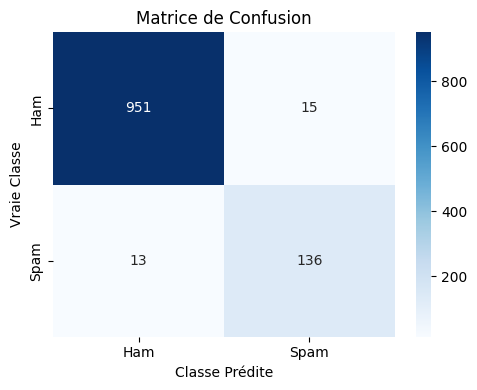

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur le set de test
y_pred = mlp.predict(X_test_scaled)

print("\n📊 Rapport de Classification :")
print(classification_report(y_test, y_pred, target_names=['Ham (0)', 'Spam (1)']))

print(f"Accuracy globale : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score (Spam)  : {f1_score(y_test, y_pred):.4f}")

# Matrice de confusion visuelle
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Vraie Classe')
plt.xlabel('Classe Prédite')
plt.title('Matrice de Confusion')
plt.tight_layout()
plt.show()

#### Courbe de perte & Sauvegarde

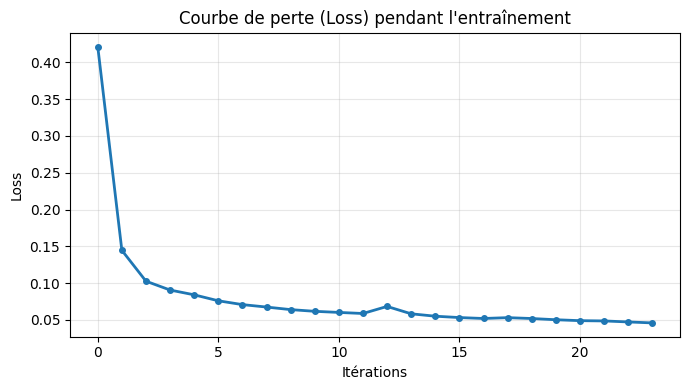

💾 Pipeline complet sauvegardé dans 'spam_detector_pipeline.pkl'


In [38]:
# 1. Visualisation de la courbe de perte (convergence)
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, marker='o', markersize=4, linewidth=2)
plt.title('Courbe de perte (Loss) pendant l\'entraînement')
plt.xlabel('Itérations')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Sauvegarde du modèle final + scaler
import joblib

pipeline = {
    'mlp': mlp,
    'scaler': scaler,
    'fasttext_model_path': 'fasttext_spam_model.model'
}

joblib.dump(pipeline, './spam_detector_pipeline.pkl')
print("💾 Pipeline complet sauvegardé dans 'spam_detector_pipeline.pkl'")